 ## Note
 **Perceptronの分類則:**
 $$ \hat{y} =
 \begin{cases}
 1, & w \cdot x + b \geq 0,\\
 -1, & \mathrm{otherwise}.
 \end{cases}
 $$
 平面$w \cdot x + b = 0$を分類境界として符号で判定するアルゴリズム

 **更新則:** 1サンプルあたりの損失は以下の定義(パーセプトロン損失)
 $$l(x; w, b) = max(0, -y(w \cdot x + b))$$
 正分類で0、誤分類で$w \cdot x + b$の損失<br/>
 パラメータ$w$と$b$について$l(x)$を最小化するための勾配は
 $$ \frac{\partial l}{\partial w} =-yx$$
 $$ \frac{\partial l}{\partial b} = -y$$
 更新則は$\eta$を学習率として、以下
 $$ w \leftarrow w + \eta yx $$
 $$ b \leftarrow b + \eta y $$

In [ ]:
import tempfile
from abc import ABC, abstractmethod
from copy import deepcopy
from dataclasses import dataclass
from pathlib import Path
from typing import Self

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display
from matplotlib.animation import FuncAnimation
from matplotlib.axes import Axes
from numpy.typing import ArrayLike, NDArray
from sklearn.datasets import make_blobs

rng = np.random.default_rng(seed=123)


@dataclass
class LogItem:
    model: "Classifier"
    x: NDArray | None = None
    y: int | None = None


@dataclass
class History:
    Dx: NDArray
    Dy: NDArray | None
    epochs: int

    def __post_init__(self):
        self.values: list[LogItem] = []

    def append(self, item: LogItem):
        self.values.append(item)

    def __getitem__(self, key: int):
        return self.values[key]

    def __len__(self) -> int:
        return len(self.values)


class Classifier(ABC):
    def __init__(self, ndim: int = 2, eta: float = 0.01):
        self.eta = eta
        self.w: NDArray = rng.standard_normal(ndim)
        self.b: float = rng.standard_normal(1)[0]

    @abstractmethod
    def train(self, Dx: NDArray, Dy: NDArray, epochs: int = 100) -> History: ...

    def decision_boundary(
        self,
        xlim: tuple[float, float],
        ylim: tuple[float, float],
    ) -> NDArray:
        x0 = np.linspace(*xlim, 80)
        x1 = np.linspace(*ylim, 80)
        X0, X1 = np.meshgrid(x0, x1)

        grid_points = np.column_stack([X0.ravel(), X1.ravel()])
        score = self.score(grid_points).reshape(X0.shape)

        contour = plt.contour(X0, X1, score, levels=[0])
        X = np.concatenate(
            [path.vertices for path in contour.get_paths()],
            axis=0,
        )
        plt.close()

        return X

    def score(self, X: NDArray) -> NDArray:
        return X @ self.w + self.b

    def predict(self, X: NDArray) -> NDArray:
        return np.sign(self.score(X))

    def copy(self) -> Self:
        return deepcopy(self)


class Perceptron(Classifier):
    def __init__(self, ndim: int = 2, eta: float = 0.01):
        super().__init__(ndim=ndim, eta=eta)

    def train(self, Dx: NDArray, Dy: NDArray, epochs: int = 100) -> History:
        history = History(Dx, Dy, epochs)
        history.append(LogItem(self.copy()))

        for i in range(epochs):
            errors = 0
            for x_i, y_i in zip(Dx, Dy):
                if y_i * self.predict(x_i) <= 0:
                    history.append(LogItem(self.copy(), x_i, y_i))
                    self.w, self.b = self._train_step(x_i, y_i)
                    errors += 1
            print(f"epoch {i + 1}: {errors} errors")
            if errors == 0:
                break
        return history

    def _train_step(self, x: NDArray, y: float) -> tuple[NDArray, float]:
        w = self.w + self.eta * y * x
        b = self.b + self.eta * y
        return (w, b)


def init_blobs_dataset(
    centers: NDArray | ArrayLike, cluster_std: float = 1.0, n_samples: int = 300
) -> tuple[NDArray, NDArray]:
    centers = np.asarray(centers)

    X, y = make_blobs(  # type: ignore
        n_samples=n_samples,  # 全サンプル数（100 samples/class * 2）
        n_features=2,  # 特徴量の次元数
        centers=centers,  # 各クラスの平均ベクトル
        cluster_std=cluster_std,  # 標準偏差
        random_state=123,
        shuffle=True,
    )
    y = np.where(y == 0, 1, -1)

    return (X, y)

In [ ]:
class TrainLogAnimation:
    def __init__(
        self,
        history: History,
        xlim: tuple[float, float],
        ylim: tuple[float, float],
    ):
        self.history = history
        self.xlim = xlim
        self.ylim = ylim

        x_range = np.linspace(*xlim, 40)
        y_range = np.linspace(*ylim, 40)
        self.X_grid, self.Y_grid = np.meshgrid(x_range, y_range)
        self.grid = np.stack([self.X_grid, self.Y_grid], axis=-1)

        self._quiver_params = {
            "angles": "xy",
            "scale_units": "xy",
            "scale": 1,
        }

    def plot(
        self,
        interval: int = 150,
        figsize: tuple[int, int] = (5, 5),
        frame_sampling_rate: float = 1.0,
        heatmap: bool = True,
        decision_boundary: bool = True,
        update: bool = True,
    ) -> Image:
        fig, ax = plt.subplots(figsize=figsize)
        ax.set_aspect("equal")

        n_frames = len(self.history)
        n_samples = max(1, round(n_frames * frame_sampling_rate))

        frame_indexes = np.linspace(
            0,
            n_frames - 1,
            n_samples,
            dtype=int,
        )
        print(f"""{n_frames = }, {n_samples = }""")

        ani = FuncAnimation(
            fig,
            self._animate,
            frames=frame_indexes,
            interval=interval,
            repeat=False,
            fargs=(ax, heatmap, decision_boundary, update),
        )
        plt.close(fig)

        with tempfile.TemporaryDirectory() as tmpdir:
            path = Path(tmpdir) / "anim.gif"
            ani.save(path, fps=int(1000 / interval), writer="pillow")

            data = path.read_bytes()
        return Image(data=data, format="gif")

    def _animate(
        self,
        frame_index: int,
        ax: Axes,
        heatmap: bool = True,
        decision_boundary: bool = True,
        update: bool = True,
    ):
        ax.clear()

        log = self.history[frame_index]
        log_next = None
        if frame_index < len(self.history) - 1:
            log_next = self.history[frame_index + 1]

        if heatmap:
            self.plot_heatmap(ax, log.model)
        if decision_boundary:
            self.plot_decision_boundary(ax, log.model)

        if update:
            if log_next is not None:
                self.plot_decision_boundary(ax, log_next.model, linestyle="--")
            self.plot_update(ax, log)
        self.configure_axes(ax, frame_index)

    def plot_heatmap(self, ax: Axes, model: Classifier):
        Z_grid = model.score(self.grid)
        ax.imshow(
            Z_grid,
            extent=(
                self.X_grid[0, 0],
                self.X_grid[0, -1],
                self.Y_grid[0, 0],
                self.Y_grid[-1, 0],
            ),
            origin="lower",
            aspect="auto",
            cmap="RdBu_r",
        )
        ax.scatter(
            self.history.Dx[:, 0], self.history.Dx[:, 1], c=self.history.Dy, cmap="bwr"
        )

    def plot_decision_boundary(self, ax: Axes, model: Classifier, **kwargs):
        boundary = model.decision_boundary(self.xlim, self.ylim)
        ax.plot(boundary[:, 0], boundary[:, 1], **kwargs)

    def plot_update(self, ax: Axes, log: LogItem):
        if log.x is not None and log.y is not None:
            ax.scatter(log.x[0], log.x[1], c="lime", marker="D")

            delta = log.y * log.x
            ax.quiver(*log.model.w, *delta, color=["green"], **self._quiver_params)

        ax.quiver(0, 0, *log.model.w, color=["green"], **self._quiver_params)

    def configure_axes(self, ax: Axes, frame_index: int):
        ax.set_xlim(*self.xlim)
        ax.set_ylim(*self.ylim)
        ax.set_title(f"Updated: {frame_index}")

epoch 1: 63 errors
epoch 2: 5 errors
epoch 3: 4 errors
epoch 4: 3 errors
epoch 5: 3 errors
epoch 6: 2 errors
epoch 7: 1 errors
epoch 8: 1 errors
epoch 9: 1 errors
epoch 10: 1 errors
epoch 11: 0 errors
n_frames = 85, n_samples = 85


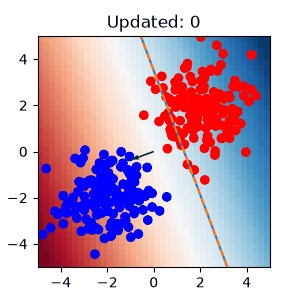

In [ ]:
def main():
    Dx, Dy = init_blobs_dataset(centers=[[2, 2], [-2, -2]])

    model = Perceptron()
    history = model.train(Dx, Dy)
    output_frames = 150
    frame_sampling_rate = min(1.0, output_frames / len(history))

    log_anim = TrainLogAnimation(
        history,
        xlim=(-5, 5),
        ylim=(-5, 5),
    )
    display(log_anim.plot(figsize=(3, 3), frame_sampling_rate=frame_sampling_rate))


if __name__ == "__main__":
    main()